In [1]:
# Quick import sanity check
from src.data import load_german_credit_data, clean_german_credit_data
from src.preprocessing import get_feature_columns, build_preprocessor
from src.train import apply_smote, train_lightgbm
from src.evaluate import evaluate_binary_classifier
from src.explain import compute_tree_shap_values, compute_global_shap_importance

print("All src imports OK")


c:\Users\admin\AppData\Local\Programs\Python\Python313\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


All src imports OK


In [2]:
# ### CELL 1 - Install required packages (run first)
! pip install --quiet lightgbm xgboost shap lime scikit-learn imbalanced-learn matplotlib pandas numpy joblib


[notice] A new release of pip is available: 25.2 -> 25.3
[notice] To update, run: python.exe -m pip install --upgrade pip


In [3]:
# ### CELL 2 - Imports and output folder

import os
import json
import joblib
import warnings
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from lime.lime_tabular import LimeTabularExplainer

warnings.filterwarnings("ignore")

OUT = "/content/credit_project_outputs"
os.makedirs(OUT, exist_ok=True)

# For reproducibility
RND = 42


In [4]:
# ### CELL 3 - Download UCI German Credit dataset

from src.data import load_german_credit_data

print("Downloading dataset from UCI...")
df = load_german_credit_data()
print("Downloaded rows:", df.shape[0])

Downloaded rows: 1000


In [5]:
# ### CELL 4 - Clean & typed dataframe

from src.data import clean_german_credit_data

df = clean_german_credit_data(df)

# Quick sanity
print("Default distribution (1=default):", df["default"].value_counts().to_dict())

Default distribution (1=default): {0: 700, 1: 300}


In [6]:
# ### CELL 5 - Feature engineering & preprocessing plan

from src.preprocessing import get_feature_columns

num_cols, cat_cols = get_feature_columns(df, target_col="default")

print("Numeric cols:", num_cols)
print("Categorical cols:", cat_cols)
print(
    "Default distribution (1=default):",
    df["default"].value_counts().to_dict(),
)


Numeric cols: ['Duration_months', 'Credit_amount', 'Installment_rate', 'Present_residence_since', 'Age_years', 'Number_existing_credits', 'Number_people_liable']
Categorical cols: ['Status_checking_account', 'Credit_history', 'Purpose', 'Savings_account_bonds', 'Present_employment_since', 'Personal_status_sex', 'Other_debtors_guarantors', 'Property', 'Other_installment_plans', 'Housing', 'Job', 'Telephone', 'Foreign_worker']
Default distribution (1=default): {0: 700, 1: 300}


In [7]:
# ### CELL 6 - Train/val/test split
from sklearn.model_selection import train_test_split

X = df.drop(columns=['default']).copy()
y = df['default'].copy()
X_train, X_temp, y_train, y_temp = train_test_split(X, y, test_size=0.30, stratify=y, random_state=RND)
X_val, X_test, y_val, y_test = train_test_split(X_temp, y_temp, test_size=0.5, stratify=y_temp, random_state=RND)

In [8]:
# ### CELL 7 - Preprocessing pipeline

from src.preprocessing import build_preprocessor

preprocessor = build_preprocessor(num_cols, cat_cols)

preprocessor.fit(X_train)

X_train_p = preprocessor.transform(X_train)
X_val_p = preprocessor.transform(X_val)
X_test_p = preprocessor.transform(X_test)

# feature names after preprocessing
feature_names = list(num_cols) + list(
    preprocessor.named_transformers_["cat"]
    .named_steps["ohe"]
    .get_feature_names_out(cat_cols)
)

print("Feature count after preprocessing:", len(feature_names))


Feature count after preprocessing: 61


In [9]:
# ### CELL 8 - Handle class imbalance (SMOTE)

from src.train import apply_smote

X_train_res, y_train_res = apply_smote(
    X_train_p,
    y_train,
    random_state=RND
)

print("After SMOTE class counts:", np.bincount(y_train_res))


After SMOTE class counts: [490 490]


In [10]:
# ### CELL 9 - Model training & hyperparameter tuning (LightGBM)

from src.train import train_lightgbm

best, best_params = train_lightgbm(
    X_train_res,
    y_train_res,
    random_state=RND
)

print("Best params:", best_params)

joblib.dump(best, os.path.join(OUT, "best_model_lgb.joblib"))


Fitting 4 folds for each of 25 candidates, totalling 100 fits
[LightGBM] [Info] Number of positive: 490, number of negative: 490
[LightGBM] [Info] Auto-choosing row-wise multi-threading, the overhead of testing was 0.000988 seconds.
You can set `force_row_wise=true` to remove the overhead.
And if memory is not enough, you can set `force_col_wise=true`.
[LightGBM] [Info] Total Bins 1544
[LightGBM] [Info] Number of data points in the train set: 980, number of used features: 58
[LightGBM] [Info] [binary:BoostFromScore]: pavg=0.500000 -> initscore=0.000000
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best ga

['/content/credit_project_outputs\\best_model_lgb.joblib']

In [13]:
# ### CELL 10 - Evaluate and threshold tuning

from src.evaluate import evaluate_binary_classifier
from sklearn.metrics import f1_score

# Validation metrics at default threshold
metrics_val, probs_val = evaluate_binary_classifier(best, X_val_p, y_val, threshold=0.5)
print("Validation metrics:", metrics_val)

# Test metrics at default threshold
metrics_test, probs_test = evaluate_binary_classifier(best, X_test_p, y_test, threshold=0.5)
print("Test metrics:", metrics_test)

# Threshold tuning (maximize F1 on validation)
thresholds = np.linspace(0.01, 0.99, 99)
best_thr, best_f1 = 0.5, 0.0

for t in thresholds:
    preds = (probs_val >= t).astype(int)
    f = f1_score(y_val, preds)
    if f > best_f1:
        best_f1 = f
        best_thr = t

print("Best threshold by F1 on val:", best_thr, "F1:", best_f1)

# Save chosen threshold
with open(os.path.join(OUT, "chosen_threshold.txt"), "w") as f:
    f.write(str(best_thr))


Validation metrics: {'auc': 0.7314285714285713, 'f1': 0.449438202247191, 'precision': 0.45454545454545453, 'recall': 0.4444444444444444}
Test metrics: {'auc': 0.7748148148148148, 'f1': 0.4931506849315068, 'precision': 0.6428571428571429, 'recall': 0.4}
Best threshold by F1 on val: 0.15000000000000002 F1: 0.5693430656934306


In [14]:
from sklearn.metrics import roc_auc_score
from sklearn.calibration import CalibratedClassifierCV

def calibrate_model(model, X_val, y_val):
    cal = CalibratedClassifierCV(model, cv="prefit", method="sigmoid")
    cal.fit(X_val, y_val)
    return cal
cal = calibrate_model(best, X_val_p, y_val)
joblib.dump(cal, os.path.join(OUT, "calibrated_model.joblib"))

# Evaluate calibrated model
probs_test_cal = cal.predict_proba(X_test_p)[:,1]
print('Calibrated Test AUC:', roc_auc_score(y_test, probs_test_cal))

Calibrated Test AUC: 0.7748148148148148


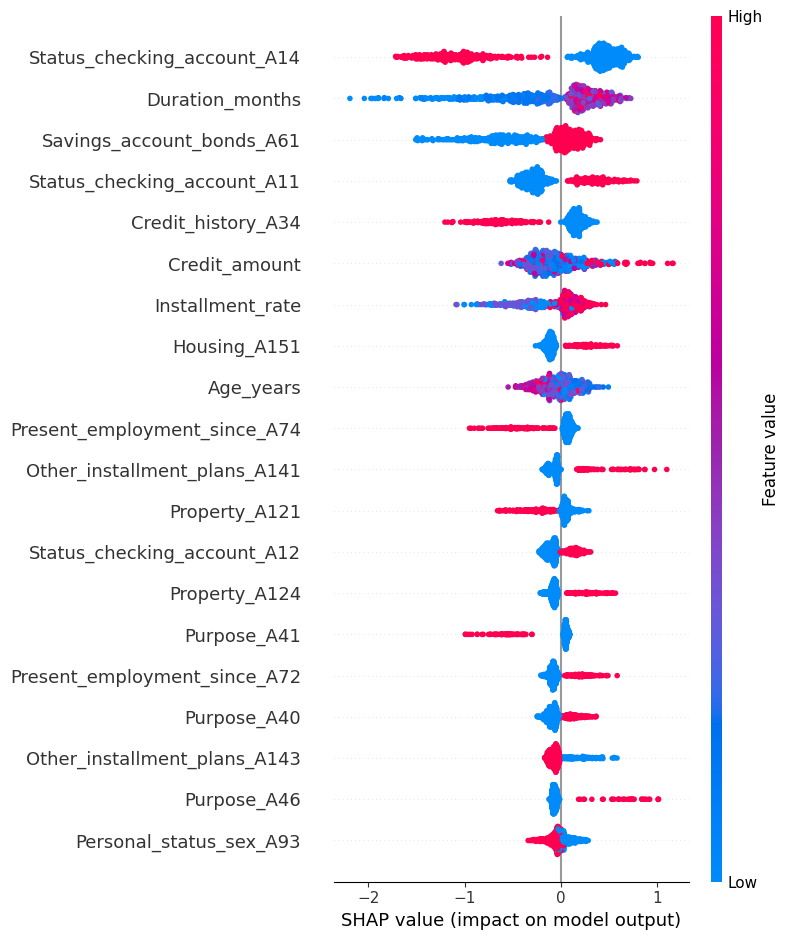

In [17]:
# ### CELL 12 - SHAP global explanations
import shap
from src.explain import compute_tree_shap_values, compute_global_shap_importance

# Compute SHAP values
shap_arr = compute_tree_shap_values(best, X_train_p)

# Global SHAP importance
shap_df = compute_global_shap_importance(shap_arr, feature_names)
shap_df.to_csv(os.path.join(OUT, "global_shap_all.csv"), index=False)

# SHAP summary plot (static)
plt.figure(figsize=(10,6))
shap.summary_plot(
    shap_arr,
    features=X_train_p,
    feature_names=feature_names,
    show=False
)
plt.tight_layout()
plt.savefig(os.path.join(OUT, "shap_summary.png"))


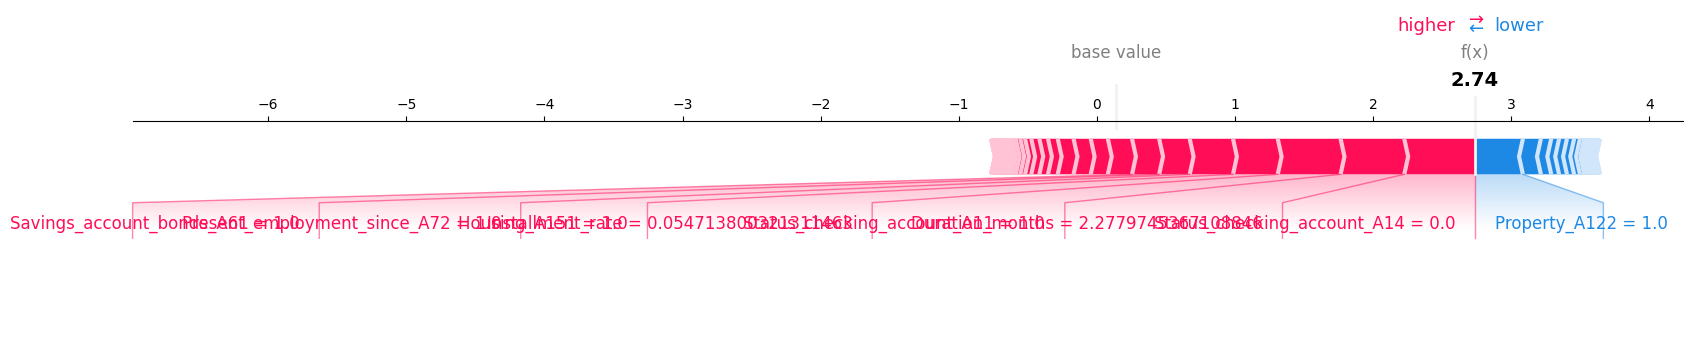

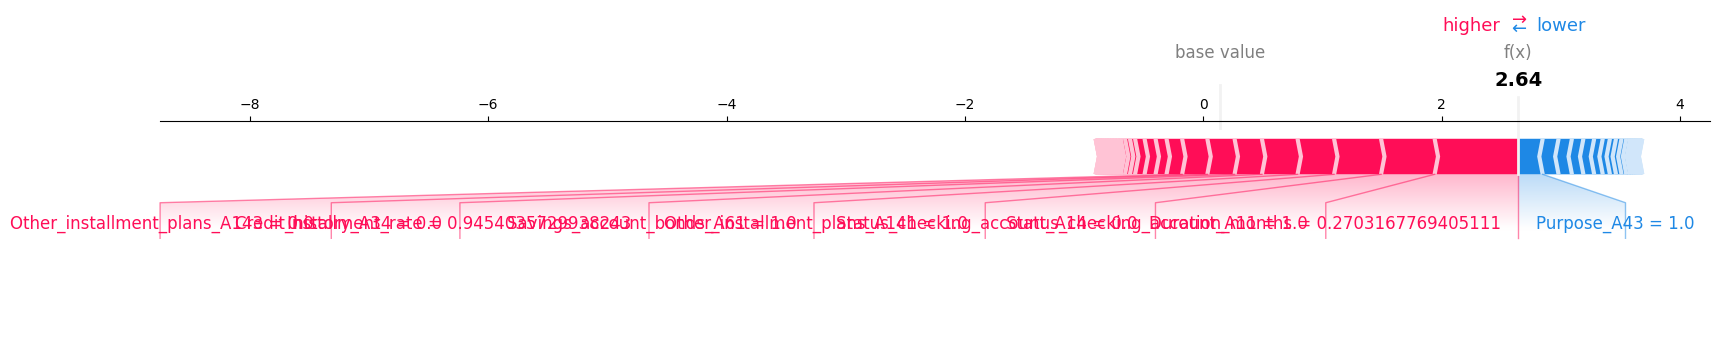

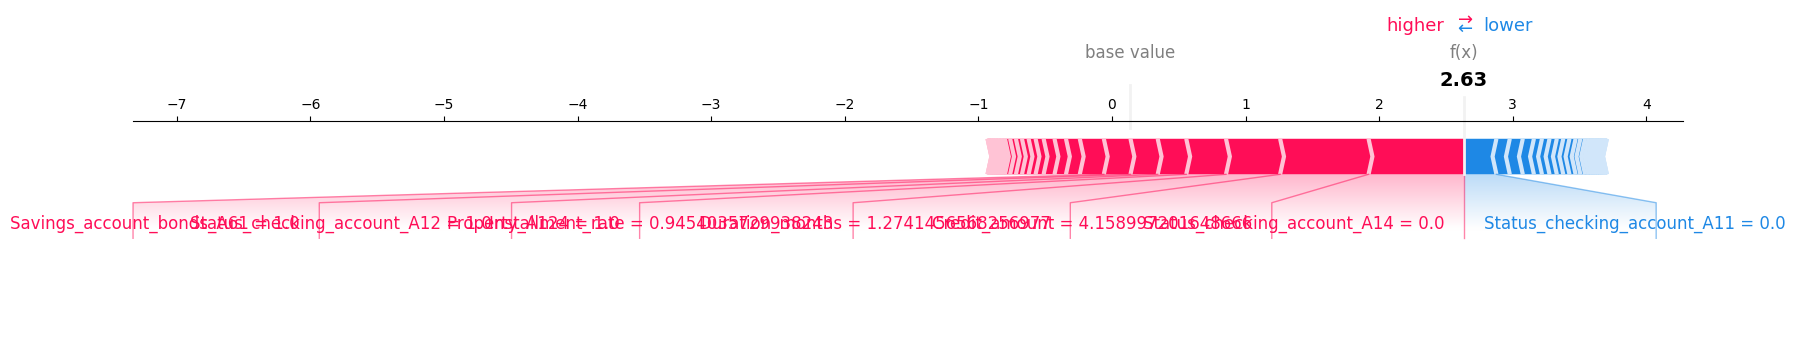

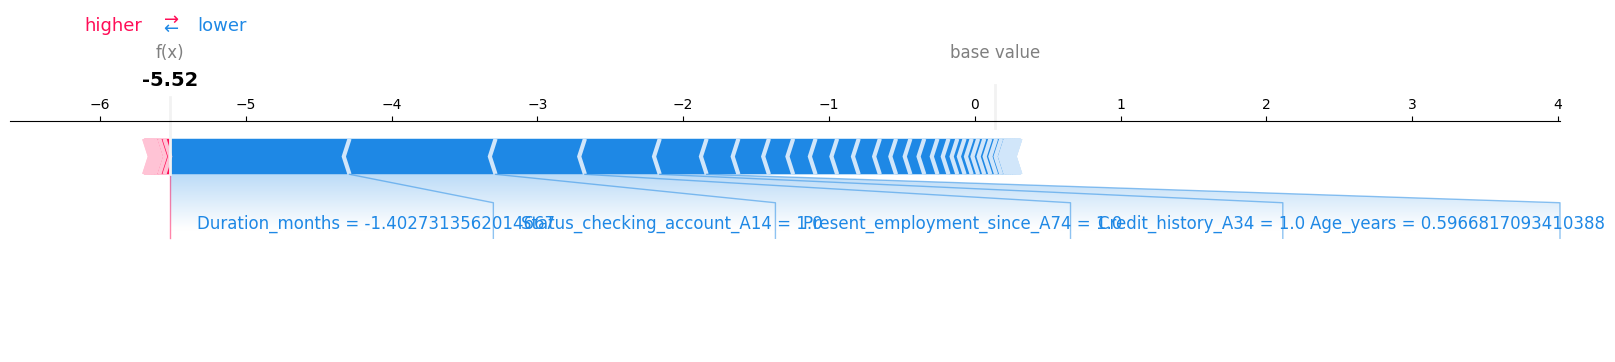

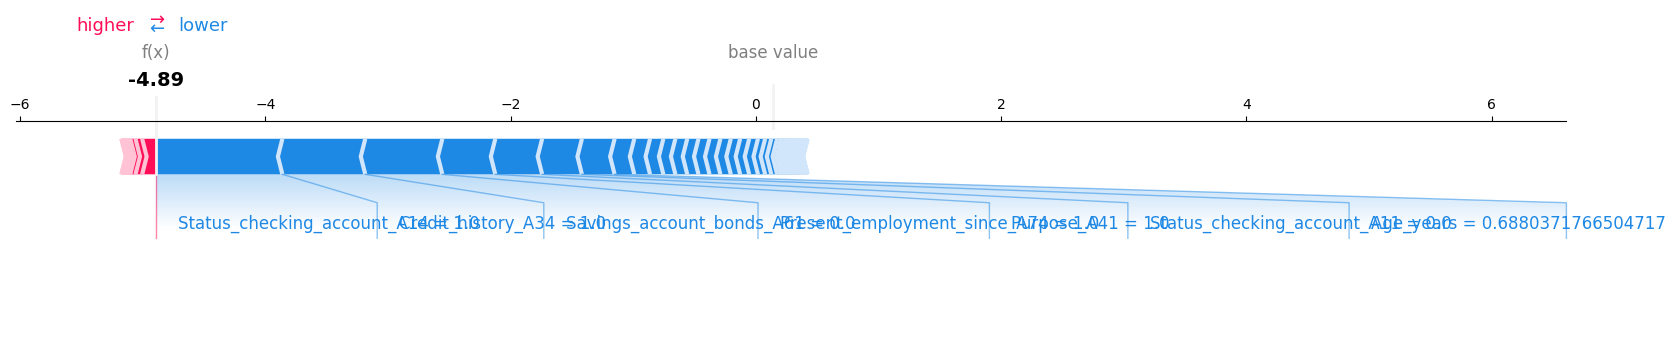

In [18]:
# ### CELL 13 - Select 5 profiles and create local SHAP explanations (text + plots)
# Select 3 high-risk + 2 low-risk by predicted probability
import shap
explainer = shap.TreeExplainer(best)

probs_test_raw = best.predict_proba(X_test_p)[:,1]
_test = X_test.reset_index(drop=True).copy(); _test['pred_prob'] = probs_test_raw; _test['true'] = y_test.reset_index(drop=True)
profiles_high = _test.sort_values('pred_prob', ascending=False).head(3)
profiles_low = _test.sort_values('pred_prob', ascending=True).head(2)
profiles = pd.concat([profiles_high, profiles_low])


local_reports = {}
for idx in profiles.index:
    row_vec = X_test_p[idx:idx+1]
    sv = explainer.shap_values(row_vec)
    sv_arr = sv[1][0] if isinstance(sv, list) else sv[0]
    contribs = list(zip(feature_names, sv_arr))
    contribs_sorted = sorted(contribs, key=lambda t: abs(t[1]), reverse=True)[:10]
    local_reports[int(idx)] = {'pred_prob': float(_test.loc[idx,'pred_prob']), 'true': int(_test.loc[idx,'true']), 'top_contribs': [{'feature':f,'shap':float(v)} for f,v in contribs_sorted]}
    # force plot saved as PNG via matplotlib
    shap.initjs()
    fig = shap.force_plot(explainer.expected_value[1] if isinstance(explainer.expected_value, (list,tuple)) else explainer.expected_value, sv_arr, row_vec, feature_names=feature_names, matplotlib=True)
    plt.savefig(os.path.join(OUT,f'force_plot_{idx}.png'))
    plt.close()


with open(os.path.join(OUT,'local_shap_reports.json'),'w') as f:
    json.dump(local_reports, f, indent=2)

In [19]:
# ### CELL 14 - LIME local explanations for 2 selected profiles
# Note: LIME is kept notebook-level as explanations are profile-specific and exploratory

lime_exp = LimeTabularExplainer(
    training_data=X_train_res,
    feature_names=feature_names,
    class_names=['no_default','default'],
    discretize_continuous=True,
    random_state=RND
)

lime_reports = {}

for idx in profiles.index[:2]:
    row = X_test_p[idx]
    exp = lime_exp.explain_instance(row, best.predict_proba, num_features=10)
    lime_reports[int(idx)] = {
        "as_list": exp.as_list(),
        "pred_prob": float(_test.loc[idx, "pred_prob"]),
        "true": int(_test.loc[idx, "true"]),
    }

with open(os.path.join(OUT, "local_lime_reports.json"), "w") as f:
    json.dump(lime_reports, f, indent=2)


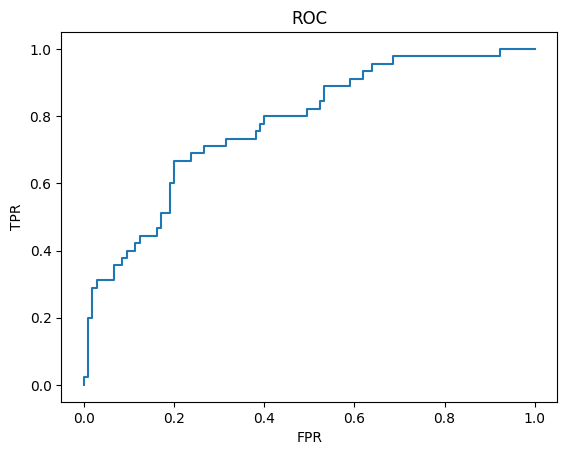

In [20]:
# ### CELL 15 - Plots: ROC, Precision-Recall, Confusion Matrix
# ROC
from sklearn.metrics import roc_curve, auc, precision_recall_curve
fpr, tpr, _ = roc_curve(y_test, probs_test)
plt.figure(); plt.plot(fpr, tpr); plt.xlabel('FPR'); plt.ylabel('TPR'); plt.title('ROC'); plt.savefig(os.path.join(OUT,'roc.png'))



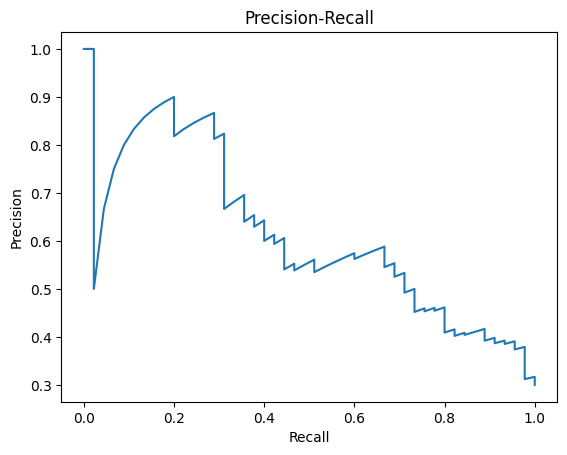

In [21]:
# Precision-Recall
prec, rec, _ = precision_recall_curve(y_test, probs_test)
plt.figure(); plt.plot(rec, prec); plt.xlabel('Recall'); plt.ylabel('Precision'); plt.title('Precision-Recall'); plt.savefig(os.path.join(OUT,'pr.png'))

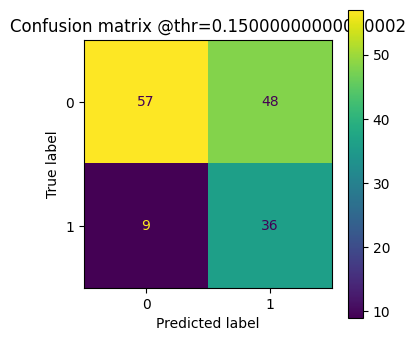

In [24]:
# Confusion matrix at chosen threshold
from sklearn.metrics import confusion_matrix
thr = float(open(os.path.join(OUT,'chosen_threshold.txt')).read())
pred_thr = (probs_test >= thr).astype(int)
from sklearn.metrics import ConfusionMatrixDisplay
cm = confusion_matrix(y_test, pred_thr)
fig, ax = plt.subplots(figsize=(4,4)); disp = ConfusionMatrixDisplay(cm).plot(ax=ax); plt.title(f'Confusion matrix @thr={thr}'); fig.savefig(os.path.join(OUT,'confusion_matrix.png'))

In [25]:
# ### CELL 16 - Executive summary & recommendations (auto-generated template)
# Build a concise 1-page executive summary using SHAP top features and model performance
with open(os.path.join(OUT,'report.md'),'w') as f:
    f.write('# Executive summary - German Credit Risk (UCI)\n\n')
    f.write('**Model:** LightGBM (tuned) with SHAP explanations.\n\n')
    f.write('**Performance (test):**\n')
    f.write(f'- AUC: {roc_auc_score(y_test, probs_test):.3f}\n')
    f.write(f'- F1 (at threshold {best_thr:.2f}): {f1_score(y_test, (probs_test>=best_thr).astype(int)):.3f}\n')
    f.write('\n**Top drivers (global SHAP):**\n')
    for i,row in shap_df.head(7).iterrows():
        f.write(f'- {row["feature"]}: mean |SHAP| = {row["mean_abs_shap"]:.6f}\n')
    f.write('\n**Top underwriting recommendations:**\n')
    f.write('- Strengthen review for applicants with high values in the top SHAP drivers.\n')
    f.write('- Consider re-pricing/raising interest or decreasing loan amount for high-risk segments.\n')
    f.write('- Add manual review for borderline profiles identified by local SHAP force plots.\n')

In [26]:
# ### CELL 17 - Package outputs

import shutil

zip_path = "/content/credit_project_outputs"
shutil.make_archive(zip_path, "zip", OUT)

print(f"All outputs saved to {OUT}")
print(f"Zip file created at {zip_path}.zip")
print("Done.")


All outputs saved to /content/credit_project_outputs
Zip file created at /content/credit_project_outputs.zip
Done.
